In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv(r"bengaluru_house_prices.csv")
data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
data.shape

(13320, 9)

In [5]:
data.isna().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [7]:
data.groupby('area_type')['area_type'].value_counts()

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: count, dtype: int64

In [8]:
# drop some columns -- not so prioritize
data.drop(['area_type','society','balcony','availability'], axis=1, inplace=True)
data.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


# Data Cleaning

In [9]:
data.isna().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [10]:
# drop all null values --- since total records is 13,000 more, and null values are very smal so we drop it
data =data.dropna()

In [11]:
data.isna().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [12]:
data.shape

(13246, 5)

In [13]:
data['size'].unique()

<ArrowStringArray>
[     '2 BHK',  '4 Bedroom',      '3 BHK',      '4 BHK',  '6 Bedroom',
  '3 Bedroom',      '1 BHK',       '1 RK',  '1 Bedroom',  '8 Bedroom',
  '2 Bedroom',  '7 Bedroom',      '5 BHK',      '7 BHK',      '6 BHK',
  '5 Bedroom',     '11 BHK',      '9 BHK',  '9 Bedroom',     '27 BHK',
 '10 Bedroom', '11 Bedroom',     '10 BHK',     '19 BHK',     '16 BHK',
 '43 Bedroom',     '14 BHK',      '8 BHK', '12 Bedroom',     '13 BHK',
 '18 Bedroom']
Length: 31, dtype: str

In [14]:
data['bhk'] = data['size'].apply(lambda x: int(x.split(' ')[0]))
data.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [15]:
data.bhk.unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [16]:
data[data.bhk > 20]

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [17]:
data.total_sqft.unique()

<ArrowStringArray>
[       '1056',        '2600',        '1440',        '1521',        '1200',
        '1170',        '2732',        '3300',        '1310',        '1020',
 ...
        '1379',        '3124',        '9200',         '613',         '250',
        '2395',        '2758', '1133 - 1384',         '774',        '4689']
Length: 2067, dtype: str

In [18]:
data.info()

<class 'pandas.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13246 non-null  str    
 1   size        13246 non-null  str    
 2   total_sqft  13246 non-null  str    
 3   bath        13246 non-null  float64
 4   price       13246 non-null  float64
 5   bhk         13246 non-null  int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 1021.2 KB


In [19]:
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True

In [20]:
data[~data['total_sqft'].apply(is_float)].head(10)

,location,size,total_sqft,bath,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,56.800,2
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,2 BHK,1195 - 1440,2.0,63.770,2
648,Arekere,9 Bedroom,4125Perch,9.0,265.000,9
661,Yelahanka,2 BHK,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,445.000,4


In [21]:
def convert_sqrt_to_num(x):
    token = x.split('-')
    if len(token) == 2:
        return (float(token[0]) + float(token[1])) / 2
    try:
        return float(x)
    except:
        return None

In [22]:
convert_sqrt_to_num('1235')

1235.0

In [23]:
convert_sqrt_to_num('2100 - 2850')

2475.0

In [24]:
convert_sqrt_to_num('4125Perch')

In [25]:
data_df = data.copy()

In [26]:
data_df['total_sqft'] = data_df['total_sqft'].apply(convert_sqrt_to_num)
data_df.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2


In [27]:
data_df.loc[30]

location      Yelahanka
size              4 BHK
total_sqft       2475.0
bath                4.0
price             186.0
bhk                   4
Name: 30, dtype: object

In [28]:
(2100 + 2850)/2

2475.0

In [29]:
data.shape

(13246, 6)

In [30]:
data_df[~data_df['total_sqft'].apply(is_float)].head(10)

,location,size,total_sqft,bath,price,bhk


In [31]:
data_df.loc[648]

location        Arekere
size          9 Bedroom
total_sqft          NaN
bath                9.0
price             265.0
bhk                   9
Name: 648, dtype: object

In [73]:
data_df.isna().sum()

location       0
size           0
total_sqft    46
bath           0
price          0
bhk            0
dtype: int64

In [74]:
data_df.isna().sum()

location       0
size           0
total_sqft    46
bath           0
price          0
bhk            0
dtype: int64

In [50]:
data_df[data_df.total_sqft.isna()]

,location,size,total_sqft,bath,price,bhk
410,Kengeri,1 BHK,NaN,1.0,18.50,1
648,Arekere,9 Bedroom,NaN,9.0,265.00,9
775,Basavanagara,1 BHK,NaN,2.0,93.00,1
872,Singapura Village,2 BHK,NaN,2.0,45.00,2
1019,Marathi Layout,1 Bedroom,NaN,1.0,110.00,1
1086,Narasapura,2 Bedroom,NaN,2.0,29.50,2
1400,Chamrajpet,9 BHK,NaN,9.0,296.00,9
1712,Singena Agrahara,3 Bedroom,NaN,3.0,95.00,3
1743,Hosa Road,3 BHK,NaN,3.0,115.00,3
1821,Sarjapur,3 Bedroom,NaN,3.0,76.00,3


In [101]:
data_df.dropna(inplace=True)
data.isna().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
bhk           0
dtype: int64

In [102]:
data_df1 = data_df.copy()
data_df1.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2


In [103]:
data_df1.isna().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
bhk           0
dtype: int64

In [104]:
data_df1['price_per_sqft'] = data_df1['price'] * 100000 / data_df1['total_sqft']
data_df1.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [105]:
data_df1.location.unique()

<ArrowStringArray>
[                       'Electronic City Phase II',
                                'Chikka Tirupathi',
                                     'Uttarahalli',
                              'Lingadheeranahalli',
                                        'Kothanur',
                                      'Whitefield',
                                'Old Airport Road',
                                    'Rajaji Nagar',
                                    'Marathahalli',
                                    'Gandhi Bazar',
 ...
                               'Masjid e Alkareem',
                                   'Sindhi Colony',
                             'Kanakapur main road',
                       'Prasanna layout Herohalli',
                               'Sarvobhogam Nagar',
                                  'Pattegarhpalya',
                                     'Tilak Nagar',
 '12th cross srinivas nagar banshankari 3rd stage',
                               'Havanur 

In [106]:
location = data_df1.groupby('location')['location'].value_counts().sort_values(ascending=False)
location

location
Whitefield                                            532
Sarjapur  Road                                        392
Electronic City                                       302
Kanakpura Road                                        264
Thanisandra                                           232
                                                     ... 
bsk 6th stage 2ad block near sri conversation hall      1
elachenahalli                                           1
kadubisnahalli                                          1
kamanahalli main road                                   1
kanakapura main road                                    1
Name: count, Length: 1298, dtype: int64

In [107]:
len(location[location <=10])

1058

In [108]:
location_less_than_10 = location[location <= 10]
location_less_than_10

location
Nagadevanahalli                                       10
BTM 1st Stage                                         10
Nagappa Reddy Layout                                  10
Sadashiva Nagar                                       10
1st Block Koramangala                                 10
                                                      ..
bsk 6th stage 2ad block near sri conversation hall     1
elachenahalli                                          1
kadubisnahalli                                         1
kamanahalli main road                                  1
kanakapura main road                                   1
Name: count, Length: 1058, dtype: int64

In [109]:
data_df1.location = data_df1.location.apply(lambda x: 'other' if x in location_less_than_10 else x)
data_df1.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [110]:
data_df1.location.nunique()

241

In [111]:
data_df1.isna().sum()

location          0
size              0
total_sqft        0
bath              0
price             0
bhk               0
price_per_sqft    0
dtype: int64

In [112]:
# lets suppose per bed -- 300 sqft
# display data where per bed area is less than 300 sqft
data_df1[data_df1.total_sqft / data_df1.bhk < 300]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274.509804
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333.333333
58,Murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6,10660.980810
68,other,8 Bedroom,1350.0,7.0,85.0,8,6296.296296
70,other,3 Bedroom,500.0,3.0,100.0,3,20000.000000
...,...,...,...,...,...,...,...
13277,other,7 Bedroom,1400.0,7.0,218.0,7,15571.428571
13279,other,6 Bedroom,1200.0,5.0,130.0,6,10833.333333
13281,Margondanahalli,5 Bedroom,1375.0,5.0,125.0,5,9090.909091
13303,Vidyaranyapura,5 Bedroom,774.0,5.0,70.0,5,9043.927649


In [113]:
# the above results are unusual.. data errors or outliers
data_df1.shape

(13200, 7)

In [118]:
data_df2 = data_df1[~ (data_df1.total_sqft / data_df1.bhk < 300)]
data_df2.shape

(12456, 7)

In [119]:
data_df2.price_per_sqft.describe()

count     12456.000000
mean       6308.502826
std        4168.127339
min         267.829813
25%        4210.526316
50%        5294.117647
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

In [122]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft > (m-st)) & (subdf.price_per_sqft <=(m+st))]
        df_out = pd.concat([df_out,reduced_df], ignore_index=False)
    return df_out

In [123]:
data_df3 = remove_pps_outliers(data_df2)
data_df3.shape

(10245, 7)

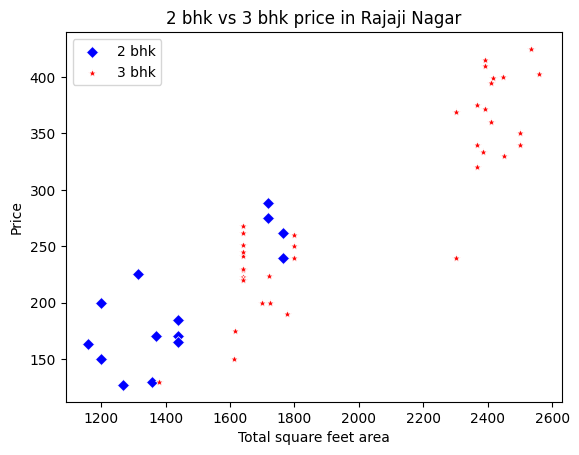

In [132]:
# compare 2 bhk and 3 bhk price 
# since, some 2 bhk price is higher than 3 bhk for same location?

def plot_scatter_chart(df, location):
    bhk2 = df[(df.location == location) & (df.bhk==2)]
    bhk3 = df[(df.location == location) & (df.bhk==3)]
    sns.scatterplot(x=bhk2.total_sqft, y=bhk2.price, color='blue', label='2 bhk', marker='D')
    sns.scatterplot(x=bhk3.total_sqft, y=bhk3.price, color='red', label='3 bhk', marker='*')
    plt.xlabel('Total square feet area')
    plt.ylabel('Price')
    plt.title(f"2 bhk vs 3 bhk price in {location}")
    plt.legend()
    plt.show()
plot_scatter_chart(data_df3,'Rajaji Nagar')

In [134]:
# here some 2 bhk price is greater than 3 bhk price at same location
# one 3 bhk price is less than 2 bhk price
# outliers removed

In [135]:
data_df3.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
152,Devarachikkanahalli,3 BHK,1250.0,2.0,44.0,3,3520.000000
341,Devarachikkanahalli,2 BHK,1250.0,2.0,40.0,2,3200.000000
2474,Devarachikkanahalli,2 Bedroom,1200.0,2.0,83.0,2,6916.666667
5030,Devarachikkanahalli,2 BHK,1170.0,2.0,40.0,2,3418.803419
5771,Devarachikkanahalli,3 BHK,1425.0,2.0,65.0,3,4561.403509


In [136]:
data_df3.location.unique()

<ArrowStringArray>
[     ' Devarachikkanahalli',       '1st Block Jayanagar',
        '1st Phase JP Nagar', '2nd Phase Judicial Layout',
      '2nd Stage Nagarbhavi',      '5th Block Hbr Layout',
        '5th Phase JP Nagar',        '6th Phase JP Nagar',
        '7th Phase JP Nagar',        '8th Phase JP Nagar',
 ...
      'Vishveshwarya Layout',        'Vishwapriya Layout',
               'Vittasandra',                'Whitefield',
            'Yelachenahalli',                 'Yelahanka',
        'Yelahanka New Town',               'Yelenahalli',
              'Yeshwanthpur',                     'other']
Length: 241, dtype: str

In [161]:
data_df3.groupby('location')[['location','bhk']].value_counts(ascending=False).reset_index()

,location,bhk,count
0,Devarachikkanahalli,2,8
1,Devarachikkanahalli,3,5
2,1st Block Jayanagar,4,3
3,1st Block Jayanagar,3,3
4,1st Block Jayanagar,2,1
...,...,...,...
790,other,9,4
791,other,11,2
792,other,10,2
793,other,16,1


In [162]:
# here we remove those for e.g 2 bhk apartments whose price_per_sqft is less than the mean price_per_sqft of 1 bhk appartment

def remove_bhk_outliers(df):
    exclude_indices= np.array([])
    for location, location_df in data_df3.groupby('location'):
        bhk_stats={}
        for bhk,bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std':np.std(bhk_df.price_per_sqft),
                'count':bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft < (stats['mean'])].index.values)
    return df.drop(exclude_indices, axis='index')

In [163]:
data_df4 = remove_bhk_outliers(data_df3)
data_df4.shape

(7331, 7)

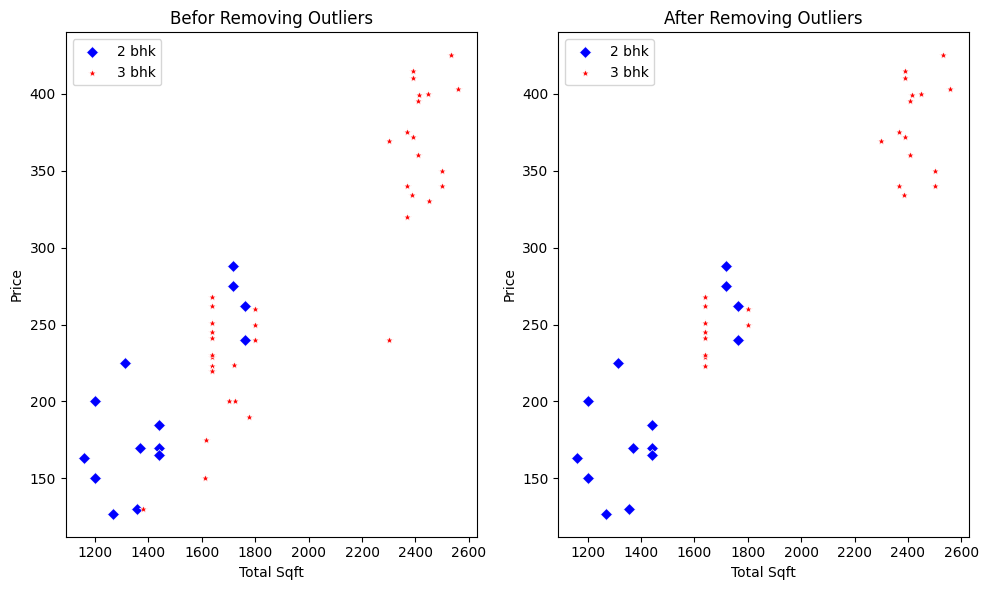

In [171]:
def plot_scatter_chart(ax, df, location):
    bhk2 = df[(df.location == location) & (df.bhk==2)]
    bhk3 = df[(df.location == location) & (df.bhk==3)]
    sns.scatterplot(x=bhk2.total_sqft, y=bhk2.price, ax=ax,color='blue', label='2 bhk', marker='D')
    sns.scatterplot(x=bhk3.total_sqft, y=bhk3.price, ax=ax, color='red', label='3 bhk', marker='*')
    ax.set_xlabel("Total Sqft")
    ax.set_ylabel("Price")
    ax.legend()

fig , axes = plt.subplots(1,2,figsize=(10,6))
plot_scatter_chart(axes[0], data_df3,'Rajaji Nagar')
plot_scatter_chart(axes[1], data_df4,'Rajaji Nagar')
axes[0].set_title("Befor Removing Outliers")
axes[1].set_title("After Removing Outliers")
plt.tight_layout()
plt.show()

<Axes: xlabel='price_per_sqft', ylabel='Count'>

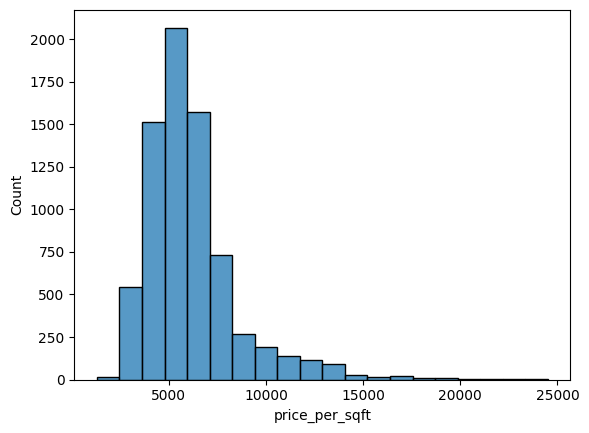

In [174]:
sns.histplot(data=data_df4, x=data_df4.price_per_sqft, bins=20)

In [175]:
data_df4.bath.unique()

array([ 2.,  3.,  4.,  5.,  8.,  1.,  6.,  7.,  9., 12., 16., 13.])

In [176]:
data_df4[data_df4.bath >10]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
8636,Neeladri Nagar,10 BHK,4000.0,12.0,160.0,10,4000.000000
3096,other,10 BHK,12000.0,12.0,525.0,10,4375.000000
3609,other,16 BHK,10000.0,16.0,550.0,16,5500.000000
7979,other,11 BHK,6000.0,12.0,150.0,11,2500.000000
9935,other,13 BHK,5425.0,13.0,275.0,13,5069.124424


Text(0, 0.5, 'Count')

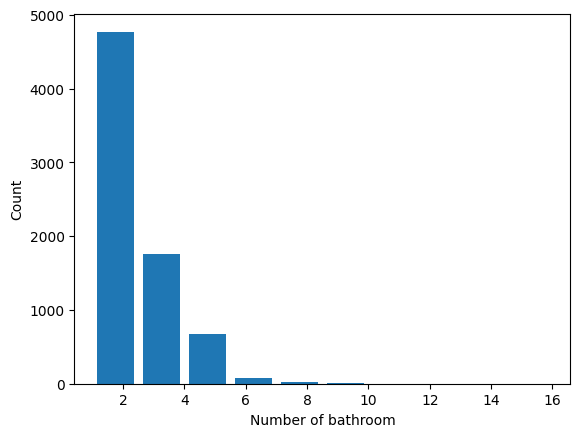

In [179]:
plt.hist(data_df4.bath,rwidth=0.8)
plt.xlabel("Number of bathroom")
plt.ylabel("Count")

In [185]:
# lets take -- if number of bathroom is greater than number of bedroom + 2 ---- its outliers
bath_outliers = data_df4[data_df4.bath > data_df4.bhk + 2]
bath_outliers

,location,size,total_sqft,bath,price,bhk,price_per_sqft
7709,Chikkabanavar,4 Bedroom,2460.0,7.0,80.0,4,3252.032520
11366,Nagasandra,4 Bedroom,7000.0,8.0,450.0,4,6428.571429
12103,Thanisandra,3 BHK,1806.0,6.0,116.0,3,6423.034330
2620,other,6 BHK,11338.0,9.0,1000.0,6,8819.897689


In [186]:
bath_outliers.shape

(4, 7)

In [187]:
data_df4.shape

(7331, 7)

In [188]:
# remove the records with more bathroom
data_df5 = data_df4[data_df4.bath < data_df4.bhk + 2]
data_df5.shape

(7253, 7)

Text(0, 0.5, 'Count')

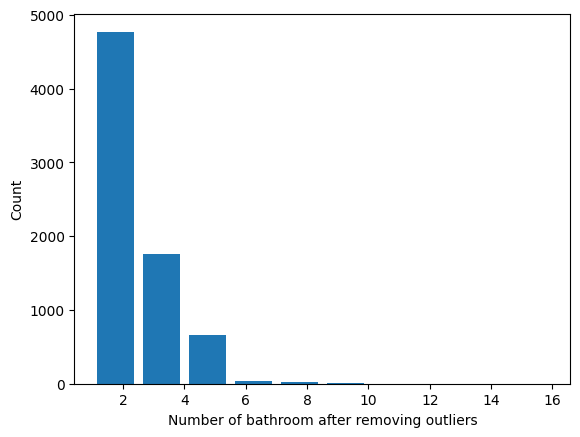

In [189]:
plt.hist(data_df5.bath,rwidth=0.8)
plt.xlabel("Number of bathroom after removing outliers")
plt.ylabel("Count")

In [190]:
data_df5.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
341,Devarachikkanahalli,2 BHK,1250.0,2.0,40.0,2,3200.000000
2474,Devarachikkanahalli,2 Bedroom,1200.0,2.0,83.0,2,6916.666667
5030,Devarachikkanahalli,2 BHK,1170.0,2.0,40.0,2,3418.803419
5771,Devarachikkanahalli,3 BHK,1425.0,2.0,65.0,3,4561.403509
6591,Devarachikkanahalli,2 BHK,947.0,2.0,43.0,2,4540.654699


In [191]:
data_df6 = data_df5.drop(['size','price_per_sqft'], axis=1)
data_df6.head()

,location,total_sqft,bath,price,bhk
341,Devarachikkanahalli,1250.0,2.0,40.0,2
2474,Devarachikkanahalli,1200.0,2.0,83.0,2
5030,Devarachikkanahalli,1170.0,2.0,40.0,2
5771,Devarachikkanahalli,1425.0,2.0,65.0,3
6591,Devarachikkanahalli,947.0,2.0,43.0,2


In [192]:
pd.get_dummies(data_df6.location)

,Devarachikkanahalli,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
341,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2474,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5030,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5771,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6591,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13238,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
13245,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
13285,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
13291,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [194]:
dummies = pd.get_dummies(data_df6.location, dtype='int')
dummies.head()

,Devarachikkanahalli,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
341,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2474,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5030,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5771,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6591,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [195]:
data_df7 = pd.concat([data_df6,dummies.drop('other', axis=1)], axis='columns')
data_df7.head()

,location,total_sqft,bath,price,bhk,Devarachikkanahalli,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
341,Devarachikkanahalli,1250.0,2.0,40.0,2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2474,Devarachikkanahalli,1200.0,2.0,83.0,2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5030,Devarachikkanahalli,1170.0,2.0,40.0,2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5771,Devarachikkanahalli,1425.0,2.0,65.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6591,Devarachikkanahalli,947.0,2.0,43.0,2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [196]:
data_df8 = data_df7.drop('location', axis='columns')
data_df8.head()

,total_sqft,bath,price,bhk,Devarachikkanahalli,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
341,1250.0,2.0,40.0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2474,1200.0,2.0,83.0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5030,1170.0,2.0,40.0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5771,1425.0,2.0,65.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6591,947.0,2.0,43.0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [197]:
data_df8.shape

(7253, 244)

In [198]:
X = data_df8.drop('price',axis='columns')
X.head()

,total_sqft,bath,bhk,Devarachikkanahalli,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
341,1250.0,2.0,2,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2474,1200.0,2.0,2,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5030,1170.0,2.0,2,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5771,1425.0,2.0,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6591,947.0,2.0,2,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [199]:
y = data_df8.price
y.head()

341     40.0
2474    83.0
5030    40.0
5771    65.0
6591    43.0
Name: price, dtype: float64

In [200]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [201]:
from sklearn.linear_model import LinearRegression

In [202]:
lr = LinearRegression()
lr.fit(X_train,y_train)
lr.score(X_test,y_test)

0.8595687461071829

In [209]:
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
import pandas as pd

def find_best_model_using_gridsearchcv(X, y):

    algos = {
        'linearRegression': {
            'model': LinearRegression(),
            'params': {}
        },

        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [1, 2],
                'selection': ['random', 'cyclic']
            }
        },

        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion': ['squared_error', 'friedman_mse'],
                'splitter': ['best', 'random']
            }
        }
    }

    scores = []
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

    for algo_name, config in algos.items():
        gs = GridSearchCV(
            config['model'],
            config['params'],
            cv=cv,
            return_train_score=False
        )
        gs.fit(X, y)

        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })

    return pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])

In [210]:
find_best_model_using_gridsearchcv(X,y)

D:\my project\codeit_datascience\data_science\venv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
10 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "D:\my project\codeit_datascience\data_science\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\my project\codeit_datascience\data_science\venv\Lib\site-packages\sklearn\base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "D:\my project\cod

,model,best_score,best_params
0,linearRegression,0.848456,{}
1,lasso,0.709007,"{'alpha': 1, 'selection': 'cyclic'}"
2,decision_tree,0.751407,"{'criterion': 'squared_error', 'splitter': 'be..."


In [211]:
X.columns

Index(['total_sqft', 'bath', 'bhk', ' Devarachikkanahalli',
       '1st Block Jayanagar', '1st Phase JP Nagar',
       '2nd Phase Judicial Layout', '2nd Stage Nagarbhavi',
       '5th Block Hbr Layout', '5th Phase JP Nagar',
       ...
       'Vijayanagar', 'Vishveshwarya Layout', 'Vishwapriya Layout',
       'Vittasandra', 'Whitefield', 'Yelachenahalli', 'Yelahanka',
       'Yelahanka New Town', 'Yelenahalli', 'Yeshwanthpur'],
      dtype='str', length=243)

In [213]:
np.where(X.columns =='1st Phase JP Nagar')[0][0]

np.int64(5)

In [214]:
def predict_price(location, sqft, bath, bhk):
    loc_index = np.where(X.columns == location)[0][0]
    x = np.zeros(len(X.columns))
    x[0] = sqft
    x[1] = bath
    x[2] = bhk

    if loc_index >=0:
        x[loc_index] = 1
    return lr.predict([x])[0]

In [215]:
predict_price('Vijayanagar',1200,2,4)

D:\my project\codeit_datascience\data_science\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(80.5032817719118)

In [217]:
predict_price('Vijayanagar',1000,3,3)

D:\my project\codeit_datascience\data_science\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(65.12606791818192)

In [218]:
predict_price('Indira Nagar',1000,3,3)

D:\my project\codeit_datascience\data_science\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(169.6244686330266)

In [219]:
import joblib


In [220]:
joblib.dump(lr,"house_price_prediction.pkl")

['house_price_prediction.pkl']

In [221]:
import json

In [223]:
columns = {
    'data_columns':[col.lower() for col in X.columns]
}
with open('columns.json','w') as f:
    f.write(json.dumps(columns))

In [224]:
columns

{'data_columns': ['total_sqft',
  'bath',
  'bhk',
  ' devarachikkanahalli',
  '1st block jayanagar',
  '1st phase jp nagar',
  '2nd phase judicial layout',
  '2nd stage nagarbhavi',
  '5th block hbr layout',
  '5th phase jp nagar',
  '6th phase jp nagar',
  '7th phase jp nagar',
  '8th phase jp nagar',
  '9th phase jp nagar',
  'aecs layout',
  'abbigere',
  'akshaya nagar',
  'ambalipura',
  'ambedkar nagar',
  'amruthahalli',
  'anandapura',
  'ananth nagar',
  'anekal',
  'anjanapura',
  'ardendale',
  'arekere',
  'attibele',
  'beml layout',
  'btm 2nd stage',
  'btm layout',
  'babusapalaya',
  'badavala nagar',
  'balagere',
  'banashankari',
  'banashankari stage ii',
  'banashankari stage iii',
  'banashankari stage v',
  'banashankari stage vi',
  'banaswadi',
  'banjara layout',
  'bannerghatta',
  'bannerghatta road',
  'basavangudi',
  'basaveshwara nagar',
  'battarahalli',
  'begur',
  'begur road',
  'bellandur',
  'benson town',
  'bharathi nagar',
  'bhoganhalli',
  